In [1]:
# import modules
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import pickle

import shap
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# paths and configuration
cwd = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(cwd, "..", ".."))

# build paths inside the repo
get_data_path = lambda folders, fname: os.path.normpath(
    os.path.join(BASE_DIR, *folders, fname)
)

file_path_training_data = get_data_path(['data', 'output', 'models'], 'training_data.csv')
pairs_for_shap_path = get_data_path(['data', 'output', 'breast_cancer'], 'pairs_for_shap.csv')

file_RF_model_contextualised = get_data_path(['data', 'output', 'models'], 'contextualised_model.pickle')
file_RF_model_full = get_data_path(['data', 'output', 'models'], 'full_model.pickle')


In [3]:
# load training data
training_df = pd.read_csv(file_path_training_data)
training_df[:3]

,genepair,A1,A2,A1_entrez,A2_entrez,DepMap_ID,cell_line,Gemini_FDR,raw_LFC,SL,...,colocalisation,interact,n_total_ppi,fet_ppi_overlap,gtex_spearman_corr,gtex_min_mean_expr,gtex_max_mean_expr,GEMINI,LFC,SL_new
0,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000022,PATU8988S_PANCREAS,0.998944,0.088856,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.118768,0.088856,False
1,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000307,PK1_PANCREAS,0.986587,0.201704,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.132501,0.201704,False
2,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000632,HS944T_SKIN,1.000000,0.069772,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.024593,0.069772,False


In [4]:
feature_columns_1 = ['rMaxExp_A1A2', 'rMinExp_A1A2',
                     'max_ranked_A1A2', 'min_ranked_A1A2',
                     'max_cn', 'min_cn', 'Protein_Altering', 'Damaging', 
                     'min_sequence_identity',
                     'prediction_score', 
                     'weighted_PPI_essentiality', 'weighted_PPI_expression',
                     'smallest_BP_GO_essentiality', 'smallest_CC_GO_essentiality',
                     'smallest_BP_GO_expression', 'go_CC_expression'
                     ]

target_column = 'SL_new'

print('num of features:', len(feature_columns_1))

num of features: 16


In [5]:
feature_columns_2 = feature_columns_1 + ['closest', 'WGD', 'family_size',
                                         'cds_length_ratio', 'shared_domains', 'has_pombe_ortholog',
                                         'has_essential_pombe_ortholog', 'has_cerevisiae_ortholog',
                                         'has_essential_cerevisiae_ortholog', 'conservation_score', 'mean_age',
                                         'either_in_complex', 'mean_complex_essentiality', 'colocalisation',
                                         'interact', 'n_total_ppi', 'fet_ppi_overlap',
                                         'gtex_spearman_corr', 'gtex_min_mean_expr', 'gtex_max_mean_expr']
feature_columns_2.remove('prediction_score')
print('num of features:', len(feature_columns_2))

num of features: 35


## Supp Fig 5a - Contextualised model SHAP (global)

In [6]:
# Load RF classifier from file
with open(file_RF_model_contextualised, 'rb') as file:
    contextualised = pickle.load(file)

In [7]:
feature_labels = {
    'rMaxExp_A1A2':                 'Gene Expression (max)',
    'rMinExp_A1A2':                 'Gene Expression (min)',
    'max_ranked_A1A2':              'Gene Essentiality (max)',
    'min_ranked_A1A2':              'Gene Essentiality (min)',
    'max_cn':                       'Copy Number (max)',
    'min_cn':                       'Copy Number (min)',
    'Protein_Altering':             'Protein Altering Mutation',
    'Damaging':                     'Damaging Mutation',
    'min_sequence_identity':        'Sequence Identity',
    'prediction_score':             'Context-Agnostic Classifier',
    'weighted_PPI_essentiality':    'Essentiality of Shared wPPIs',
    'weighted_PPI_expression':      'Expression of Shared wPPIs',
    'smallest_BP_GO_essentiality':  'GO BP Essentiality (smallest)',
    'smallest_CC_GO_essentiality':  'GO CC Essentiality (smallest)',
    'smallest_BP_GO_expression':    'GO BP Expression (smallest)',
    'go_CC_expression':             'GO CC Expression (smallest)',
}

In [8]:
sample_df = training_df.reset_index(drop=True)
print(f"Sample: {len(sample_df)} rows | {sample_df['SL_new'].sum()} SL | {(~sample_df['SL_new']).sum()} nonSL")

X_sample = sample_df[feature_columns_1].copy()
X_sample_labeled = X_sample.rename(columns=feature_labels)

Sample: 41244 rows | 958 SL | 40286 nonSL


In [ ]:
# SHAP — batched with progress bar
explainer = shap.TreeExplainer(contextualised)
batch_size = 500
batches = [X_sample.iloc[i:i+batch_size] for i in range(0, len(X_sample), batch_size)]
shap_batches = []

for batch in tqdm(batches, desc='Computing SHAP values'):
    sv = explainer.shap_values(batch)
    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        shap_batches.append(sv[:, :, 1])   
    else:
        shap_batches.append(sv[1])    

shap_values_sl = np.vstack(shap_batches)
print(shap_values_sl.shape)  # should be (4999, 16)

In [ ]:
# Save SHAP values
np.save(
    get_data_path(['data', 'output', 'models'], 'shap_values_contextualised_full.npy'),
    shap_values_sl
)

# Save the matching feature-value matrix (with pretty labels)
X_sample_labeled.to_parquet(
    get_data_path(['data', 'output', 'models'], 'shap_X_contextualised_full.parquet')
)

In [ ]:
mean_abs_shap = np.mean(np.abs(shap_values_sl), axis=0)

shap_importance_df = pd.DataFrame({
    'feature': feature_columns_1,
    'feature_label': [feature_labels[f] for f in feature_columns_1],
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance_df

In [ ]:
shap_importance_df.to_csv(
    get_data_path(['data', 'output', 'models'], 'shap_importance_contextualised_complete_dataset.csv'),
    index=False
)

In [9]:
# ── Reload previously computed SHAP artifacts (skip the compute cell above)
shap_values_sl   = np.load(
    get_data_path(['data', 'output', 'models'], 'shap_values_contextualised_full.npy')
)
X_sample_labeled = pd.read_parquet(
    get_data_path(['data', 'output', 'models'], 'shap_X_contextualised_full.parquet')
)

print(f"Loaded: SHAP {shap_values_sl.shape} | X {X_sample_labeled.shape}")

Loaded: SHAP (41244, 16) | X (41244, 16)


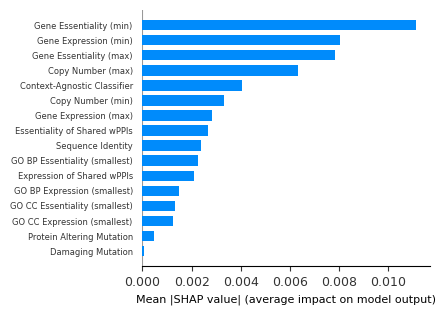

In [10]:
fig, ax = plt.subplots(figsize=(4.5, 3.25))
plt.sca(ax)

shap.summary_plot(
    shap_values_sl,
    X_sample_labeled,
    plot_type='bar',
    plot_size=None,
    show=False,
)

ax = plt.gca()
ax.set_xlabel('Mean |SHAP value| (average impact on model output)', fontsize=8)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params('y', labelsize=6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig(get_data_path(['figures', 'supp_figures'], 'sup_fig8_shap_bar_contextualised.png'), dpi=500, bbox_inches='tight')
plt.show()


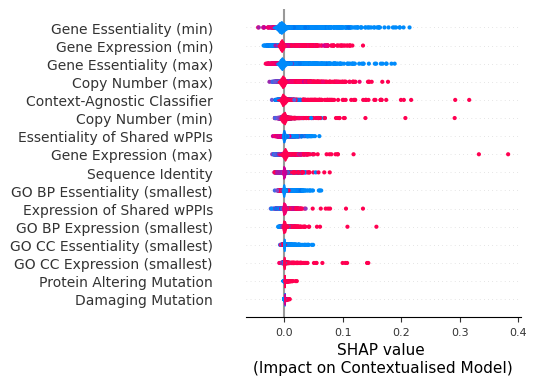

In [11]:
rng = np.random.default_rng(42)
n_plot = 5000
idx = rng.choice(len(shap_values_sl), size=min(n_plot, len(shap_values_sl)), replace=False)

shap.plots.violin(
    shap_values_sl[idx],
    X_sample_labeled.iloc[idx],
    plot_type='violin',
    plot_size=(5.5, 4),
    show=False,
    color_bar=False,
)

ax = plt.gca()
ax.set_xlabel('SHAP value \n(Impact on Contextualised Model)', fontsize=11)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(left=0.4)
#plt.tight_layout()
#plt.savefig(get_data_path(['figures', 'supp_figures'], 'sup_fig8_shap_violin_contextualised_full.png'),
#            dpi=500, bbox_inches='tight')
plt.show()

## Supp Fig 5b - Full model SHAP (global)

In [12]:
# Load RF classifier from file
with open(file_RF_model_full, 'rb') as file:
    full = pickle.load(file)

In [13]:
feature_labels_full = {
    'rMaxExp_A1A2':                 'Gene Expression (max)',
    'rMinExp_A1A2':                 'Gene Expression (min)',
    'max_ranked_A1A2':              'Gene Essentiality (max)',
    'min_ranked_A1A2':              'Gene Essentiality (min)',
    'max_cn':                       'Copy Number (max)',
    'min_cn':                       'Copy Number (min)',
    'Protein_Altering':             'Protein Altering Mutation',
    'Damaging':                     'Damaging Mutation',
    'min_sequence_identity':        'Sequence Identity',
    'prediction_score':             'Context-Agnostic Classifier',
    'weighted_PPI_essentiality':    'Essentiality of Shared wPPIs',
    'weighted_PPI_expression':      'Expression of Shared wPPIs',
    'smallest_BP_GO_essentiality':  'GO BP Essentiality (smallest)',
    'smallest_CC_GO_essentiality':  'GO CC Essentiality (smallest)',
    'smallest_BP_GO_expression':    'GO BP Expression (smallest)',
    'go_CC_expression':             'GO CC Expression (smallest)',
    'closest':                             'Closest Paralog',
    'WGD':                                 'Whole Genome Duplicates',
    'family_size':                         'Family Size',
    'cds_length_ratio':                    'Gene Length Ratio',
    'shared_domains':                      'Shared Domains',
    'has_pombe_ortholog':                  r'$\it{S.\ pombe}$ ortholog',
    'has_essential_pombe_ortholog':        r'Essential $\it{S.\ pombe}$ ortholog',
    'has_cerevisiae_ortholog':             r'$\it{S.\ cerevisiae}$ ortholog',
    'has_essential_cerevisiae_ortholog':   r'Essential $\it{S.\ cerevisiae}$ ortholog',
    'conservation_score':                  'Conservation Score',
    'mean_age':                            'Gene Age',
    'either_in_complex':                   'Protein Complex Membership',
    'mean_complex_essentiality':           'Essentiality of Protein Complex(es)',
    'colocalisation':                      'Colocalisation',
    'interact':                            'Protein-Protein Interaction',
    'n_total_ppi':                         'Total Protein-Protein Interactors',
    'fet_ppi_overlap':                     'Protein-Protein Interactors',
    'gtex_spearman_corr':                  'Expression Correlation',
    'gtex_min_mean_expr':                  'Mean expression (Lower)',
    'gtex_max_mean_expr':                  'Mean Expression (Higher)'
}

In [14]:
X_sample_full = sample_df[feature_columns_2].copy()
X_sample_full_labeled = X_sample_full.rename(columns=feature_labels_full)
X_sample_full_labeled = X_sample_full_labeled.astype(float)

In [ ]:
# Compute SHAP for full model
explainer_full = shap.TreeExplainer(full)
batch_size = 2000                 
batches_full = [X_sample_full.iloc[i:i+batch_size] for i in range(0, len(X_sample_full), batch_size)]
shap_batches_full = []

def compute_batch(batch):
    sv = explainer_full.shap_values(batch)
    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        return sv[:, :, 1]
    return sv[1]

# n_jobs=-1 uses all cores; set to e.g. 8 to leave headroom
shap_batches_full = Parallel(n_jobs=-1, backend='loky', verbose=10)(
    delayed(compute_batch)(b) for b in batches_full
)

shap_values_full = np.vstack(shap_batches_full)
print(shap_values_full.shape)          


In [ ]:
np.save(
    get_data_path(['data', 'output', 'models'], 'shap_values_full_full.npy'),
    shap_values_full
)

X_sample_full_labeled.to_parquet(
    get_data_path(['data', 'output', 'models'], 'shap_X_full_full.parquet')
)

In [ ]:
mean_abs_shap = np.mean(np.abs(shap_values_full), axis=0)

shap_importance_df_full = pd.DataFrame({
    'feature': feature_columns_2,
    'feature_label': [feature_labels_full[f] for f in feature_columns_2],
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance_df_full

In [ ]:
shap_importance_df_full.to_csv(
    get_data_path(['data', 'output', 'models'], 'shap_importance_full_full.csv'),
    index=False
)

In [15]:
# ── Reload previously computed SHAP artifacts (skip the compute cell above)
shap_values_full      = np.load(
    get_data_path(['data', 'output', 'models'], 'shap_values_full_full.npy')
)
X_sample_full_labeled = pd.read_parquet(
    get_data_path(['data', 'output', 'models'], 'shap_X_full_full.parquet')
)

print(f"Loaded: SHAP {shap_values_full.shape} | X {X_sample_full_labeled.shape}")

Loaded: SHAP (41244, 35) | X (41244, 35)


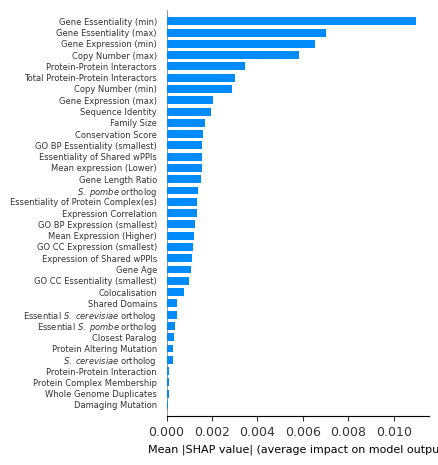

In [18]:
fig, ax = plt.subplots(figsize=(4.5, 4.75))
plt.sca(ax)

shap.summary_plot(
    shap_values_full,
    X_sample_full_labeled,
    plot_type='bar',
    plot_size=None,
    max_display=35,
    show=False,
)

ax = plt.gca()
ax.set_xlabel('Mean |SHAP value| (average impact on model output)', fontsize=8)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params('y', labelsize=6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig(get_data_path(['figures', 'supp_figures'], 'sup_fig8_shap_bar_gemini_full.png'), dpi=500, bbox_inches='tight')
plt.show()


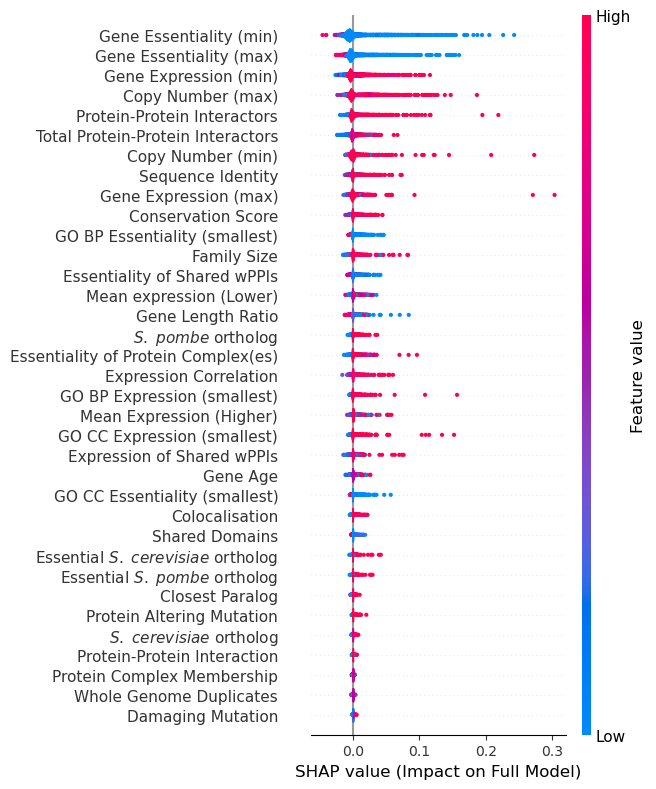

In [17]:
rng = np.random.default_rng(42)
n_plot = 5000
idx = rng.choice(len(shap_values_full), size=min(n_plot, len(shap_values_full)), replace=False)

shap.plots.violin(
    shap_values_full[idx],
    X_sample_full_labeled.iloc[idx],
    plot_type='violin',
    plot_size=(6.5, 8),
    show=False,
    color_bar=True,
    max_display=36,
)

ax=plt.gca()
ax.set_xlabel('SHAP value (Impact on Full Model)', fontsize=12)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig(
#    get_data_path(['figures','supp_figures'], 'sup_fig8_shap_violin_fullmodel_full.png'),
#    dpi=500
#)
plt.show()

## Supp Fig 12 - local SHAP examples of HER2-/+ breast cancer cell lines

In [19]:
pairs_for_shap_df = pd.read_csv(pairs_for_shap_path)
pairs_for_shap_df.head()

,prediction_rank,prediction_percentile,old_genepair,genepair,A1,A2,A1_entrez,A2_entrez,A1_ensembl,A2_ensembl,...,zA1_rank,A2_rank,zA2_rank,max_ranked_A1A2,min_ranked_A1A2,z_max_ranked_A1A2,z_min_ranked_A1A2,contextualized_prediction_score,full_prediction_score,mut_binary
0,318,0.9,AKT1_AKT2,AKT1_AKT2,AKT1,AKT2,207,208,ENSG00000142208,ENSG00000105221,...,-1.637676,2435.0,-1.384887,2435.0,1340.0,-1.384887,-1.637676,0.594942,0.605294,0.0
1,318,0.9,AKT1_AKT2,AKT1_AKT2,AKT1,AKT2,207,208,ENSG00000142208,ENSG00000105221,...,-1.615976,2040.0,-1.480457,2040.0,1428.0,-1.480457,-1.615976,0.574969,0.581038,0.0
2,318,0.9,AKT1_AKT2,AKT1_AKT2,AKT1,AKT2,207,208,ENSG00000142208,ENSG00000105221,...,-1.571835,1722.0,-1.557397,1722.0,1607.0,-1.557397,-1.571835,0.526041,0.555254,0.0
3,318,0.9,AKT1_AKT2,AKT1_AKT2,AKT1,AKT2,207,208,ENSG00000142208,ENSG00000105221,...,-1.745440,3371.0,-1.158423,3371.0,903.0,-1.158423,-1.745440,0.536079,0.551620,1.0
4,318,0.9,AKT1_AKT2,AKT1_AKT2,AKT1,AKT2,207,208,ENSG00000142208,ENSG00000105221,...,-1.453960,3050.0,-1.236088,3050.0,2085.0,-1.236088,-1.453960,0.503171,0.533599,1.0


In [20]:
HER2_COL = 'consensus_her2_status'   # or 'mut_binary'

def her2_label(v, col=HER2_COL):
    if pd.isna(v): return None
    if col == 'mut_binary':
        try: v = int(v)
        except (TypeError, ValueError): return None
        return {1: 'HER2+', 0: 'HER2-'}.get(v)
    s = str(v).strip().lower()
    if s in ('positive', 'pos', '+', '1'): return 'HER2+'
    if s in ('negative', 'neg', '-', '0'): return 'HER2-'
    return None

pairs_for_shap_df = pairs_for_shap_df.copy()
pairs_for_shap_df['her2_label'] = pairs_for_shap_df[HER2_COL].apply(her2_label)
pairs_for_shap_df = pairs_for_shap_df[pairs_for_shap_df['her2_label'].notna()].reset_index(drop=True)

print(f"{len(pairs_for_shap_df)} rows after dropping unknown HER2")
print(pairs_for_shap_df['her2_label'].value_counts())

378 rows after dropping unknown HER2
her2_label
HER2-    288
HER2+     90
Name: count, dtype: int64


In [ ]:
# Contextualised model → 16 features (feature_columns_1)
# Full model           → 35 features (feature_columns_2)

with open(file_RF_model_contextualised, 'rb') as f: contextualised = pickle.load(f)
with open(file_RF_model_full, 'rb')          as f: full           = pickle.load(f)

X_pairs_ctx  = pairs_for_shap_df[feature_columns_1].astype(float)
X_pairs_full = pairs_for_shap_df[feature_columns_2].astype(float)

def batched_shap(model, X, batch=500, desc=""):
    explainer = shap.TreeExplainer(model)
    out = []
    for i in tqdm(range(0, len(X), batch), desc=desc):
        sv = explainer.shap_values(X.iloc[i:i+batch])
        out.append(sv[:, :, 1] if (isinstance(sv, np.ndarray) and sv.ndim == 3) else sv[1])
    return np.vstack(out)

shap_values_pairs_ctx  = batched_shap(contextualised, X_pairs_ctx,  desc="SHAP (contextualised)")
shap_values_pairs_full = batched_shap(full,           X_pairs_full, desc="SHAP (full)")

pairs_for_shap_df['pSL_contextualised'] = contextualised.predict_proba(X_pairs_ctx)[:, 1]
pairs_for_shap_df['pSL_full']           = full.predict_proba(X_pairs_full)[:, 1]

print(shap_values_pairs_ctx.shape, shap_values_pairs_full.shape)

np.save(get_data_path(['data', 'output', 'models'], 'shap_values_pairs_contextualised.npy'),
        shap_values_pairs_ctx)
np.save(get_data_path(['data', 'output', 'models'], 'shap_values_pairs_full.npy'),
        shap_values_pairs_full)
pairs_for_shap_df.to_parquet(get_data_path(['data', 'output', 'models'],
                                           'pairs_for_shap_with_her2.parquet'))

In [21]:
# ── Load previously computed SHAP artifacts (skips expensive recomputation)
pairs_for_shap_df = pd.read_parquet(
    get_data_path(['data', 'output', 'models'], 'pairs_for_shap_with_her2.parquet')
)
shap_values_pairs_ctx = np.load(
    get_data_path(['data', 'output', 'models'], 'shap_values_pairs_contextualised.npy')
)
shap_values_pairs_full = np.load(
    get_data_path(['data', 'output', 'models'], 'shap_values_pairs_full.npy')
)
X_pairs_ctx  = pairs_for_shap_df[feature_columns_1].astype(float)
X_pairs_full = pairs_for_shap_df[feature_columns_2].astype(float)

print(f"Loaded {len(pairs_for_shap_df)} HER2-annotated rows | "
      f"ctx SHAP {shap_values_pairs_ctx.shape} | full SHAP {shap_values_pairs_full.shape}")
print(pairs_for_shap_df['her2_label'].value_counts())

Loaded 378 HER2-annotated rows | ctx SHAP (378, 16) | full SHAP (378, 35)
her2_label
HER2-    288
HER2+     90
Name: count, dtype: int64


In [22]:
import scipy.stats as stats, matplotlib as mpl

zmin, zmax = -2, 2
palette = sns.color_palette("coolwarm", 5)
cmap    = mpl.colors.ListedColormap(palette.as_hex())

def _zscore(x):
    if x.dtype == bool:
        return x.apply(lambda v: 2.0 if v else -2.0)
    v = x.astype(float).values
    if v.std() == 0:
        return pd.Series(np.zeros(len(v)), index=x.index)
    return pd.Series(stats.zscore(v), index=x.index).clip(zmin, zmax)

zscores_ctx = X_pairs_ctx.apply(_zscore)

top_feats_ctx = (pd.DataFrame(shap_values_pairs_ctx, columns=feature_columns_1)
                   .abs().median().sort_values(ascending=False).index.tolist())

In [23]:
# ── Per-pair, per-cell-line SHAP table with HER2 status ──────────────────
pairs_of_interest = pairs_for_shap_df['genepair'].unique().tolist()
print(f"{len(pairs_of_interest)} pairs with HER2-annotated breast cell lines")

def pair_shap_long(gp):
    mask = pairs_for_shap_df['genepair'] == gp
    if not mask.any():
        return pd.DataFrame()
    sub = (pairs_for_shap_df.loc[mask, ['cell_line', 'her2_label', 'pSL_contextualised']]
                             .reset_index(drop=True))
    sv  = shap_values_pairs_ctx[mask.values]
    zv  = zscores_ctx.loc[mask].values
    rows = []
    for i, r in sub.iterrows():
        for j, feat in enumerate(feature_columns_1):
            rows.append({
                'genepair'     : gp,
                'cell_line'    : r['cell_line'],
                'her2_label'   : r['her2_label'],
                'pSL'          : r['pSL_contextualised'],
                'feature'      : feat,
                'feature_label': feature_labels[feat],
                'shap'         : sv[i, j],
                'z'            : zv[i, j],
            })
    return pd.DataFrame(rows)

pair_shap_frames = {gp: pair_shap_long(gp) for gp in pairs_of_interest}

coverage = pd.DataFrame([
    {'genepair'    : gp,
     'n_HER2_pos'  : df.query("her2_label == 'HER2+'")['cell_line'].nunique(),
     'n_HER2_neg'  : df.query("her2_label == 'HER2-'")['cell_line'].nunique(),
     'mean_pSL'    : df['pSL'].mean(),
     'max_pSL'     : df['pSL'].max(),
     'delta_pSL'   : (df.query("her2_label == 'HER2+'")['pSL'].mean()
                     - df.query("her2_label == 'HER2-'")['pSL'].mean())}
    for gp, df in pair_shap_frames.items() if not df.empty
]).sort_values('max_pSL', ascending=False).reset_index(drop=True)

comparable_pairs = coverage.query("n_HER2_pos >= 2 and n_HER2_neg >= 2")['genepair'].tolist()
print(f"{len(comparable_pairs)} pairs have >=2 cell lines in BOTH HER2 groups.")
coverage.head(15)


9 pairs with HER2-annotated breast cell lines
9 pairs have >=2 cell lines in BOTH HER2 groups.


,genepair,n_HER2_pos,n_HER2_neg,mean_pSL,max_pSL,delta_pSL
0,AKT1_AKT2,10,32,0.247343,0.594942,0.179281
1,ASF1A_ASF1B,10,32,0.300854,0.547925,-0.000434
2,SAR1A_SAR1B,10,32,0.351808,0.535626,0.027794
3,EGFR_ERBB2,10,32,0.208487,0.512503,0.263296
4,MYB_MYBL2,10,32,0.197628,0.474004,0.163971
5,TRAF3_TRAF4,10,32,0.111110,0.443124,0.145383
6,ERBB2_ERBB3,10,32,0.167749,0.432924,0.228310
7,AP1G1_AP1G2,10,32,0.180726,0.424706,0.169641
8,GRHL1_GRHL2,10,32,0.110131,0.328061,0.137174


HER2 comparison plots:   0%|          | 0/9 [00:00<?, ?it/s]

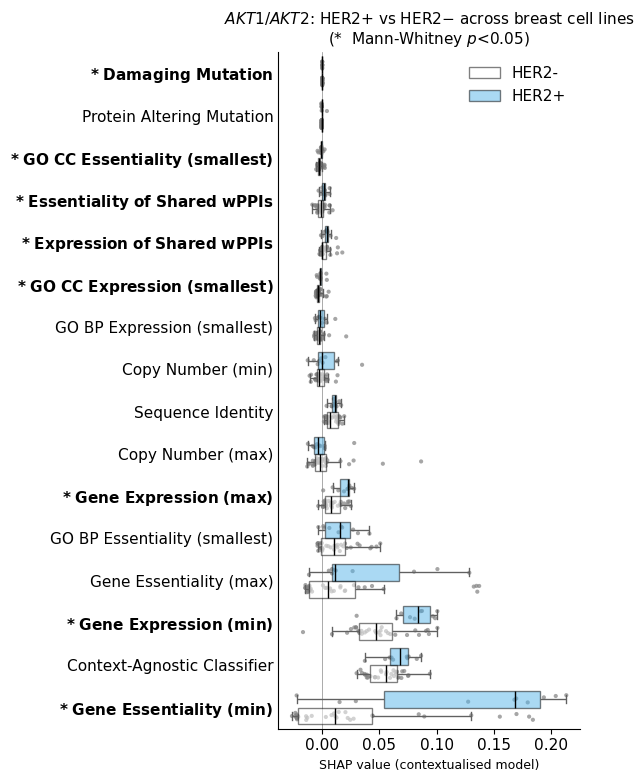

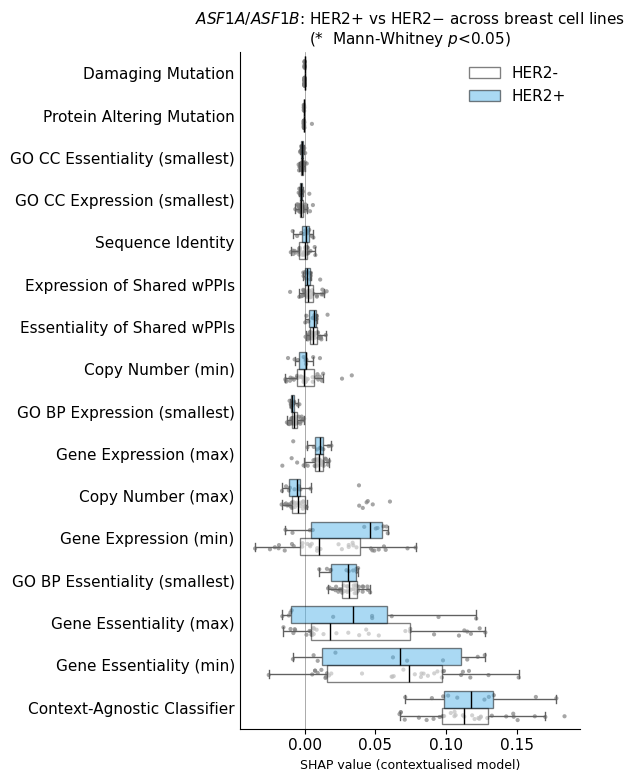

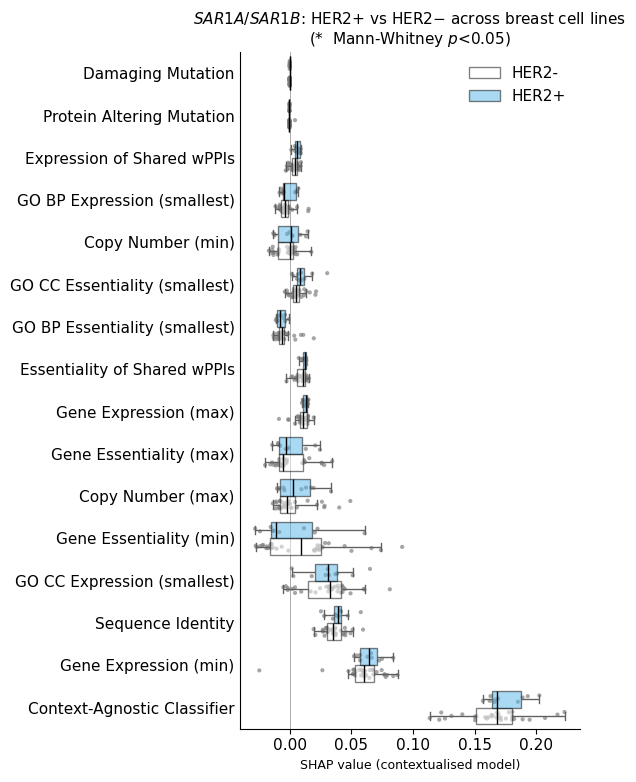

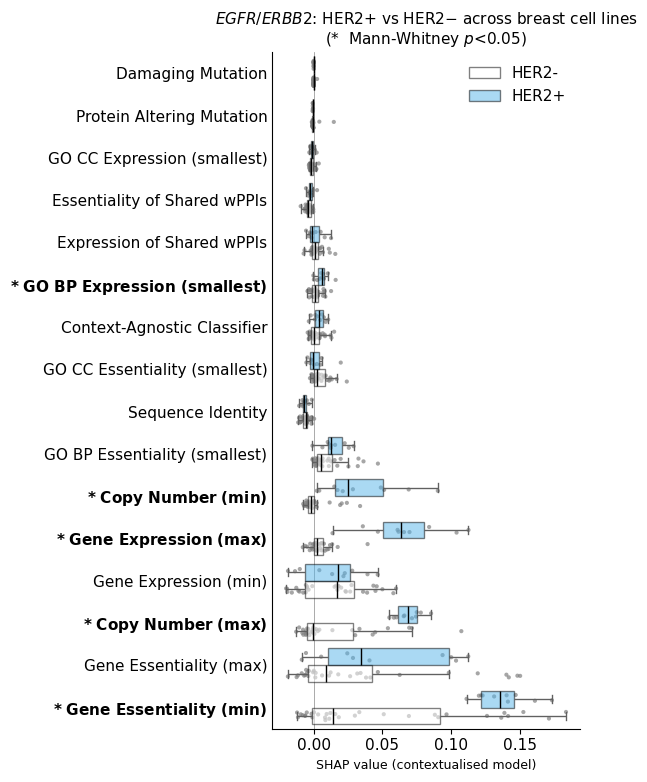

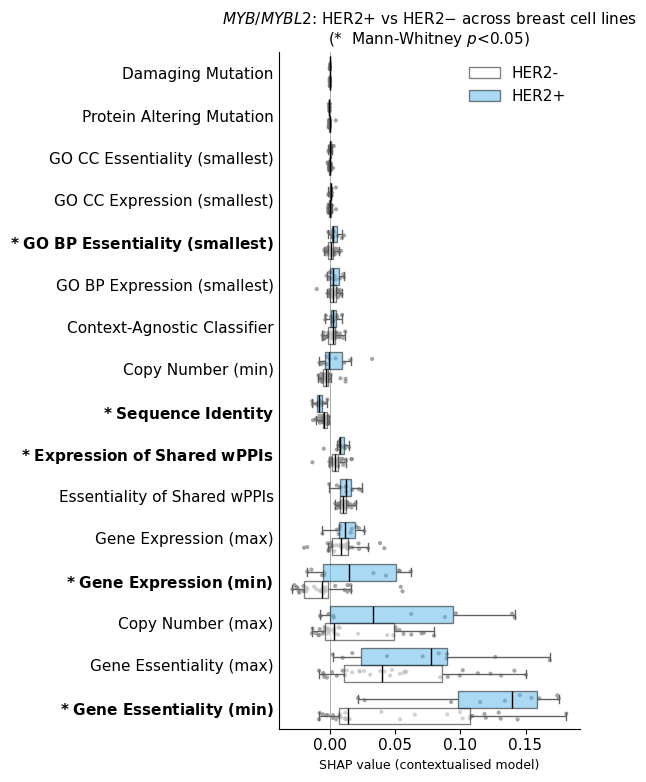

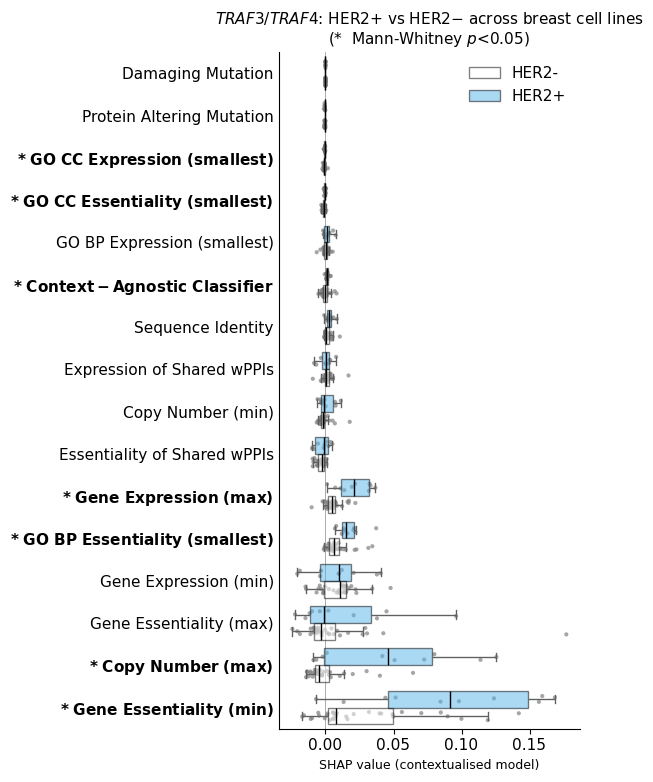

In [24]:
# ── HER2+ vs HER2- feature-influence comparison per pair ─────────────────
import scipy.stats as stats

PREVIEW_TOP_N = 6
SAVE_FIGS     = False
ALPHA         = 0.05     # significance threshold for label highlighting

HER2_BOX_PAL = {'HER2-': '#FFFFFF', 'HER2+': '#56B4E9'}
HER2_DOT_PAL = {'HER2-': 'grey',    'HER2+': 'grey'}
HER2_ORDER   = ['HER2-', 'HER2+']

def _mwu_pvalue(pos, neg):
    if len(pos) < 2 or len(neg) < 2:
        return np.nan
    try:
        return stats.mannwhitneyu(pos, neg, alternative='two-sided').pvalue
    except ValueError:
        return np.nan

def plot_her2_comparison(gp, n=10, save=False, show=True):
    df = pair_shap_frames.get(gp, pd.DataFrame())
    if df.empty:
        return None
    if not {'HER2+', 'HER2-'}.issubset(df['her2_label'].unique()):
        return None

    order = (df.groupby('feature')['shap']
               .apply(lambda s: s.abs().mean())
               .sort_values(ascending=False).index.tolist()[:n])
    d = df[df['feature'].isin(order)].copy()
    d['feature'] = pd.Categorical(d['feature'], categories=order, ordered=True)

    # Mann-Whitney per feature
    pvals = {}
    for feat in order:
        pos = d.loc[(d['feature'] == feat) & (d['her2_label'] == 'HER2+'), 'shap'].values
        neg = d.loc[(d['feature'] == feat) & (d['her2_label'] == 'HER2-'), 'shap'].values
        pvals[feat] = _mwu_pvalue(pos, neg)

    # Build y-tick labels: prefix '* ' and bold if significant
    labels = []
    for feat in order:
        base = feature_labels[feat]
        p = pvals[feat]
        if np.isfinite(p) and p < ALPHA:
            labels.append(r'$\bf{*\ ' + base.replace(' ', r'\ ') + r'}$')
        else:
            labels.append(base)

    f, ax = plt.subplots(figsize=(6.0, 0.42 * len(order) + 1.2))

    sns.boxplot(data=d, y='feature', x='shap', hue='her2_label',
                order=order, hue_order=HER2_ORDER, palette=HER2_BOX_PAL,
                showfliers=False, showmeans=False, saturation=1,
                linewidth=0.98,
                boxprops=dict(alpha=0.5, edgecolor='black'),
                medianprops=dict(linewidth=1, color='black'),
                orient='h', ax=ax)
    sns.stripplot(data=d, y='feature', x='shap', hue='her2_label',
                  order=order, hue_order=HER2_ORDER, palette=HER2_DOT_PAL,
                  dodge=True, alpha=0.7, size=3, jitter=0.2,
                  zorder=0, orient='h', ax=ax)

    # Legend: keep only the two box-color handles (drop stripplot duplicates)
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles[:2], lbls[:2], fontsize=11, frameon=False, loc='best')

    ax.axvline(0, color='#888', lw=0.5, zorder=0)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(labels, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel('SHAP value (contextualised model)', fontsize=9)
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', length=0); ax.tick_params(axis='x', labelsize=11)

    a1, a2 = gp.split('_', 1)
    ax.set_title(
        f"$\\it{{{a1}}}$/$\\it{{{a2}}}$: HER2+ vs HER2\u2212 across breast cell lines\n"
        f"(*  Mann-Whitney $p$<{ALPHA})",
        fontsize=11,
    )
    plt.tight_layout()

    if save:
        f.savefig(get_data_path(['figures', 'supp_figures',
                                 'her2_shap_compare_v2'],
                                f'sup_fig8_her2_compare_{gp}_v2.png'),
                  dpi=500, bbox_inches='tight')
    if show: plt.show()
    else:    plt.close(f)
    return f, pvals

preview_set = set(coverage[coverage['genepair'].isin(comparable_pairs)]
                  .head(PREVIEW_TOP_N)['genepair'])

for gp in tqdm(comparable_pairs, desc='HER2 comparison plots'):
    plot_her2_comparison(gp, n=16, save=SAVE_FIGS, show=(gp in preview_set))


## Full Model

In [25]:
# ── Full-model per-pair, per-cell-line SHAP table ────────────────────────
import scipy.stats as stats

zmin, zmax = -2, 2

def _zscore(x):
    if x.dtype == bool:
        return x.apply(lambda v: 2.0 if v else -2.0)
    v = x.astype(float).values
    if v.std() == 0:
        return pd.Series(np.zeros(len(v)), index=x.index)
    return pd.Series(stats.zscore(v), index=x.index).clip(zmin, zmax)

def _mwu_pvalue(pos, neg):
    if len(pos) < 2 or len(neg) < 2:
        return np.nan
    try:
        return stats.mannwhitneyu(pos, neg, alternative='two-sided').pvalue
    except ValueError:
        return np.nan

X_pairs_full = pairs_for_shap_df[feature_columns_2].astype(float)
zscores_full = X_pairs_full.apply(_zscore)

def pair_shap_long_full(gp):
    mask = pairs_for_shap_df['genepair'] == gp
    if not mask.any():
        return pd.DataFrame()
    sub = (pairs_for_shap_df.loc[mask, ['cell_line', 'her2_label', 'pSL_full']]
                             .reset_index(drop=True))
    sv  = shap_values_pairs_full[mask.values]
    zv  = zscores_full.loc[mask].values
    rows = []
    for i, r in sub.iterrows():
        for j, feat in enumerate(feature_columns_2):
            rows.append({
                'genepair'     : gp,
                'cell_line'    : r['cell_line'],
                'her2_label'   : r['her2_label'],
                'pSL'          : r['pSL_full'],
                'feature'      : feat,
                'feature_label': feature_labels_full[feat],
                'shap'         : sv[i, j],
                'z'            : zv[i, j],
            })
    return pd.DataFrame(rows)

pair_shap_frames_full = {gp: pair_shap_long_full(gp) for gp in pairs_of_interest}

HER2 comparison plots (full):   0%|          | 0/9 [00:00<?, ?it/s]

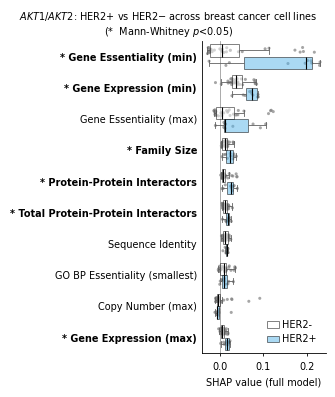

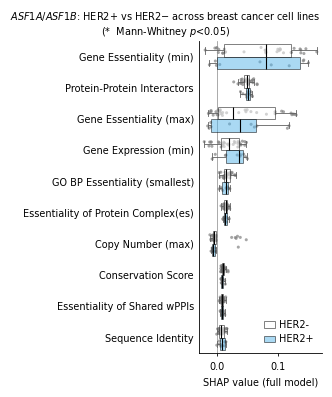

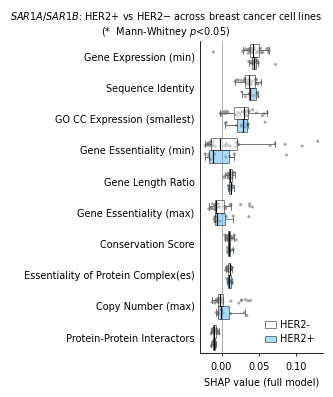

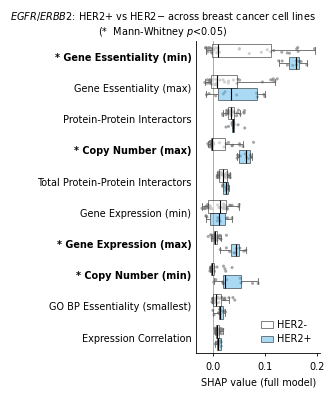

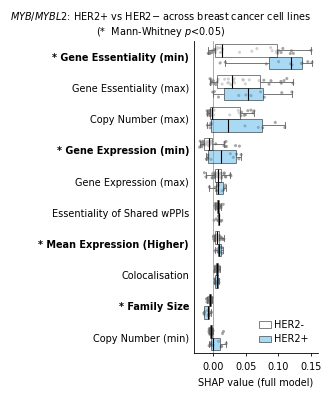

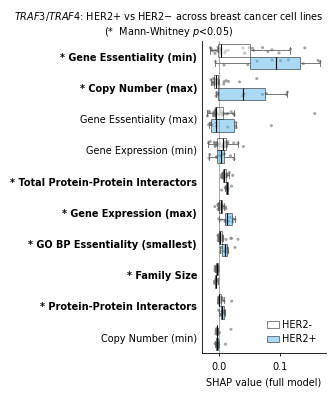

In [26]:
# ── HER2+ vs HER2- feature-influence comparison per pair (FULL MODEL) ────
PREVIEW_TOP_N = 6
SAVE_FIGS     = False
ALPHA         = 0.05

# 85 mm journal single-column width
MM_TO_IN  = 1 / 25.4
FIG_W_IN  = 85 * MM_TO_IN            # 3.346"
SAVE_DPI  = 600                       # ~2000 px wide at 85 mm — print-safe

# Compact font sizes for the small canvas (7 pt is the typical journal minimum)
FS_TICK   = 7
FS_LABEL  = 7
FS_LEGEND = 7
FS_TITLE  = 7

HER2_BOX_PAL = {'HER2-': '#FFFFFF', 'HER2+': '#56B4E9'}
HER2_DOT_PAL = {'HER2-': 'grey',    'HER2+': 'grey'}
HER2_ORDER   = ['HER2-', 'HER2+']

def plot_her2_comparison_full(gp, n=10, save=False, show=True):
    df = pair_shap_frames_full.get(gp, pd.DataFrame())
    if df.empty:
        return None
    if not {'HER2+', 'HER2-'}.issubset(df['her2_label'].unique()):
        return None

    order = (df.groupby('feature')['shap']
               .apply(lambda s: s.abs().mean())
               .sort_values(ascending=False).index.tolist()[:n])
    d = df[df['feature'].isin(order)].copy()
    d['feature'] = pd.Categorical(d['feature'], categories=order, ordered=True)

    # Mann-Whitney per feature
    pvals = {}
    for feat in order:
        pos = d.loc[(d['feature'] == feat) & (d['her2_label'] == 'HER2+'), 'shap'].values
        neg = d.loc[(d['feature'] == feat) & (d['her2_label'] == 'HER2-'), 'shap'].values
        pvals[feat] = _mwu_pvalue(pos, neg)

    labels, is_sig = [], []
    for feat in order:
        base = feature_labels_full[feat]
        p    = pvals[feat]
        sig  = np.isfinite(p) and p < ALPHA
        labels.append(('* ' + base) if sig else base)
        is_sig.append(sig)

    # Height scales with row count; a bit tighter to keep aspect reasonable at 85 mm
    fig_h = 0.28 * len(order) + 1.1
    f, ax = plt.subplots(figsize=(FIG_W_IN, fig_h))

    sns.boxplot(data=d, y='feature', x='shap', hue='her2_label',
                order=order, hue_order=HER2_ORDER, palette=HER2_BOX_PAL,
                showfliers=False, showmeans=False, saturation=1,
                linewidth=0.7,
                boxprops=dict(alpha=0.5, edgecolor='black'),
                medianprops=dict(linewidth=0.8, color='black'),
                whiskerprops=dict(linewidth=0.6),
                capprops=dict(linewidth=0.6),
                orient='h', ax=ax)
    sns.stripplot(data=d, y='feature', x='shap', hue='her2_label',
                  order=order, hue_order=HER2_ORDER, palette=HER2_DOT_PAL,
                  dodge=True, alpha=0.7, size=2.2, jitter=0.2,
                  zorder=0, orient='h', ax=ax)

    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles[:2], lbls[:2], fontsize=FS_LEGEND,
              frameon=False, loc='best', handlelength=1.2, handletextpad=0.4)

    ax.axvline(0, color='#888', lw=0.5, zorder=0)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(labels, fontsize=FS_TICK)
    for tick, sig in zip(ax.get_yticklabels(), is_sig):
        if sig:
            tick.set_fontweight('bold')
    ax.set_xlabel('SHAP value (full model)', fontsize=FS_LABEL)
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.6); ax.spines['bottom'].set_linewidth(0.6)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=FS_TICK, width=0.6, length=2.5)

    # Title centered on the FIGURE (not the axes), so it doesn't overflow the
    # 85 mm canvas when the axes are pushed right to fit long y-tick labels.
    a1, a2 = gp.split('_', 1)

    f.suptitle(
        f"$\\mathit{{{a1}}}$/$\\mathit{{{a2}}}$: HER2+ vs HER2\u2212 across breast cancer cell lines\n"
        f"(*  Mann-Whitney $p$<{ALPHA})",
        fontsize=FS_TITLE, x=0.5, y=1.0,
    )

    plt.subplots_adjust(left=0.60, right=0.97,
                        top=0.92,               # was 0.82 → raise plot area
                        bottom=0.12)

    if save:
        # NO bbox_inches='tight' → saved PNG width = FIG_W_IN (= 85 mm exactly)
        f.savefig(get_data_path(['figures', 'supp_figures',
                                 'her2_shap_compare_v2'],
                                f'sup_fig8_her2_compare_full_{gp}.png'),
                  dpi=SAVE_DPI)
    if show: plt.show()
    else:    plt.close(f)
    return f, pvals

preview_set = set(coverage[coverage['genepair'].isin(comparable_pairs)]
                  .head(PREVIEW_TOP_N)['genepair'])

for gp in tqdm(comparable_pairs, desc='HER2 comparison plots (full)'):
    plot_her2_comparison_full(gp, n=10,
                              save=SAVE_FIGS, show=(gp in preview_set))

### Per-pair feature summary (full model)

In [25]:
gp = 'AKT1_AKT2'  # or whichever pair
d  = pair_shap_frames_full[gp]

# Per-feature: mean |SHAP|, std of SHAP, and mean signed SHAP
summary = (d.groupby('feature_label')['shap']
             .agg(mean_abs=lambda s: s.abs().mean(),
                  std='std',
                  mean_signed='mean')
             .sort_values('mean_abs', ascending=False))
summary


,mean_abs,std,mean_signed
feature_label,,,
Gene Essentiality (min),0.075682,0.095101,0.060210
Gene Expression (min),0.048352,0.025549,0.047871
Gene Essentiality (max),0.031168,0.041722,0.023928
Family Size,0.014867,0.009770,0.014867
Protein-Protein Interactors,0.014578,0.012136,0.014578
Total Protein-Protein Interactors,0.013615,0.006378,0.013615
Sequence Identity,0.013581,0.005503,0.013581
GO BP Essentiality (smallest),0.011163,0.011415,0.010555
Copy Number (max),0.010721,0.020105,0.002205


In [26]:
gp = 'SAR1A_SAR1B'  # or whichever pair
d  = pair_shap_frames_full[gp]

# Per-feature: mean |SHAP|, std of SHAP, and mean signed SHAP
summary = (d.groupby('feature_label')['shap']
             .agg(mean_abs=lambda s: s.abs().mean(),
                  std='std',
                  mean_signed='mean')
             .sort_values('mean_abs', ascending=False))
summary

,mean_abs,std,mean_signed
feature_label,,,
Gene Expression (min),0.044287,0.012784,0.043763
Sequence Identity,0.037757,0.008187,0.037757
GO CC Expression (smallest),0.027291,0.016290,0.027207
Gene Essentiality (min),0.025392,0.037466,0.009327
Gene Length Ratio,0.011664,0.002890,0.011664
Gene Essentiality (max),0.011642,0.015356,-0.000257
Conservation Score,0.010340,0.003356,0.010340
Essentiality of Protein Complex(es),0.010288,0.002295,0.010288
Copy Number (max),0.009433,0.014264,0.003989
